# ECG Anomaly Detection on FPGAs via Channel-Wise Attention

End-to-end deployment of a lightweight Squeeze-and-Excitation (SE) attention
network for ECG anomaly detection on an FPGA using hls4ml.

| | |
|---|---|
| **Dataset** | ECG5000 (UCR/UEA archive) — 500 train / 4,500 test / 140 time steps |
| **Model** | SE-attention network — 1,674 parameters |
| **Target device** | Xilinx xc7z020clg400-1 |
| **Toolchain** | TensorFlow 2.20 · tf_keras · hls4ml 1.3.0 |

In [7]:
# Install all required packages.
# tensorflow and hls4ml versions are pinned for reproducibility.
!pip install -q \
    "tensorflow==2.20.0" \
    "tf_keras" \
    "hls4ml[profiling]==1.3.0" \
    "scikit-learn" \
    "matplotlib" \
    "seaborn" \
    "aeon"

## 2. Imports & Configuration

In [8]:
import warnings, json
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tf_keras as keras
import hls4ml

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    recall_score,
    roc_curve,
)

#NOTE-:

# hls4ml 1.3.0 selects its Keras parser based on keras.__version__.
# TF 2.20 ships Keras 3 as the default `keras` package; this one-line
# override routes hls4ml to its Keras-2 parser, which correctly handles
# tf_keras models built with the functional API.


import keras as _keras_compat
_keras_compat.__version__ = "2.15.0"

# Reproducibility
TRAINING_SEEDS = [42, 123, 456, 789, 2024]

# Dataset
N_TIMESTEPS = 140
N_VERIFY    = 1000     # size of stratified subset used for hardware evaluation
VERIFY_SEED = 42

# Training
BATCH_SIZE    = 32
MAX_EPOCHS    = 60
LEARNING_RATE = 5e-4
PATIENCE      = 12

# FPGA configuration
HLS_OUTPUT_DIR   = "hls_ecg_main"    # main (high precision) model
HLS_OUTPUT_LIGHT = "hls_ecg_light"   # lightweight model
FPGA_PART        = "xc7z020clg400-1"
FIXED_POINT_LIGHT = "ap_fixed<12,6>"
REUSE_FACTOR      = 1
# FIXED_POINT_MAIN is selected automatically by the precision sweep (Section 11).

# Plot style
plt.rcParams.update({
    "font.family"    : "serif",  "font.size"      : 11,
    "axes.labelsize" : 12,       "axes.titlesize" : 13,
    "xtick.labelsize": 10,       "ytick.labelsize": 10,
    "legend.fontsize": 10,       "figure.dpi"     : 120,
    "savefig.dpi"    : 300,      "savefig.bbox"   : "tight",
})

print("=" * 50)
print("Environment")
print(f"  TensorFlow : {tf.__version__}")
print(f"  hls4ml     : {hls4ml.__version__}")
print("=" * 50)

Environment
  TensorFlow : 2.20.0
  hls4ml     : 1.3.0


## 3. Dataset Loading

In [9]:
from aeon.datasets import load_classification


def load_ecg5000():
    """
    Load ECG5000 from the official UCR/UEA archive.

    Original labels (1 = Normal sinus rhythm, 2–5 = anomaly types) are
    mapped to a binary target:
        0 = Normal
        1 = Anomaly

    Returns
    -------
    X_train : ndarray, shape (500, 140, 1)
    y_train : ndarray, shape (500,)   dtype int32
    X_test  : ndarray, shape (4500, 140, 1)
    y_test  : ndarray, shape (4500,)  dtype int32
    """
    X_train, y_train = load_classification(
        "ECG5000", split="train", extract_path="/content/ucr_data"
    )
    X_test, y_test = load_classification(
        "ECG5000", split="test", extract_path="/content/ucr_data"
    )

    # Binary label mapping
    y_train = (y_train != "1").astype(np.int32)
    y_test  = (y_test  != "1").astype(np.int32)

    # Cast features to float32
    X_train = np.asarray(X_train, dtype=np.float32)
    X_test  = np.asarray(X_test,  dtype=np.float32)

    # Normalise to (N, 140, 1) regardless of archive format
    if X_train.ndim == 2:                                  # (N, 140)
        X_train = X_train[..., np.newaxis]
        X_test  = X_test[...,  np.newaxis]
    elif X_train.ndim == 3 and X_train.shape[1] == 1:     # (N, 1, 140)
        X_train = np.transpose(X_train, (0, 2, 1))
        X_test  = np.transpose(X_test,  (0, 2, 1))
    elif X_train.ndim == 4:                                # (N, 1, 140, 1)
        X_train = np.squeeze(X_train, axis=1)
        X_test  = np.squeeze(X_test,  axis=1)

    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = load_ecg5000()

assert X_train.shape == (500,  140, 1), f"Unexpected train shape: {X_train.shape}"
assert X_test.shape  == (4500, 140, 1), f"Unexpected test shape:  {X_test.shape}"

print(f"Train : {X_train.shape}   labels → {np.bincount(y_train)}")
print(f"Test  : {X_test.shape}  labels → {np.bincount(y_test)}")
print(f"\nNormal  (0): {np.sum(y_test == 0):,}  ({100 * np.mean(y_test == 0):.1f}%)")
print(f"Anomaly (1): {np.sum(y_test == 1):,}  ({100 * np.mean(y_test == 1):.1f}%)")

Train : (500, 140, 1)   labels → [292 208]
Test  : (4500, 140, 1)  labels → [2627 1873]

Normal  (0): 2,627  (58.4%)
Anomaly (1): 1,873  (41.6%)


## 4. Dataset Exploration

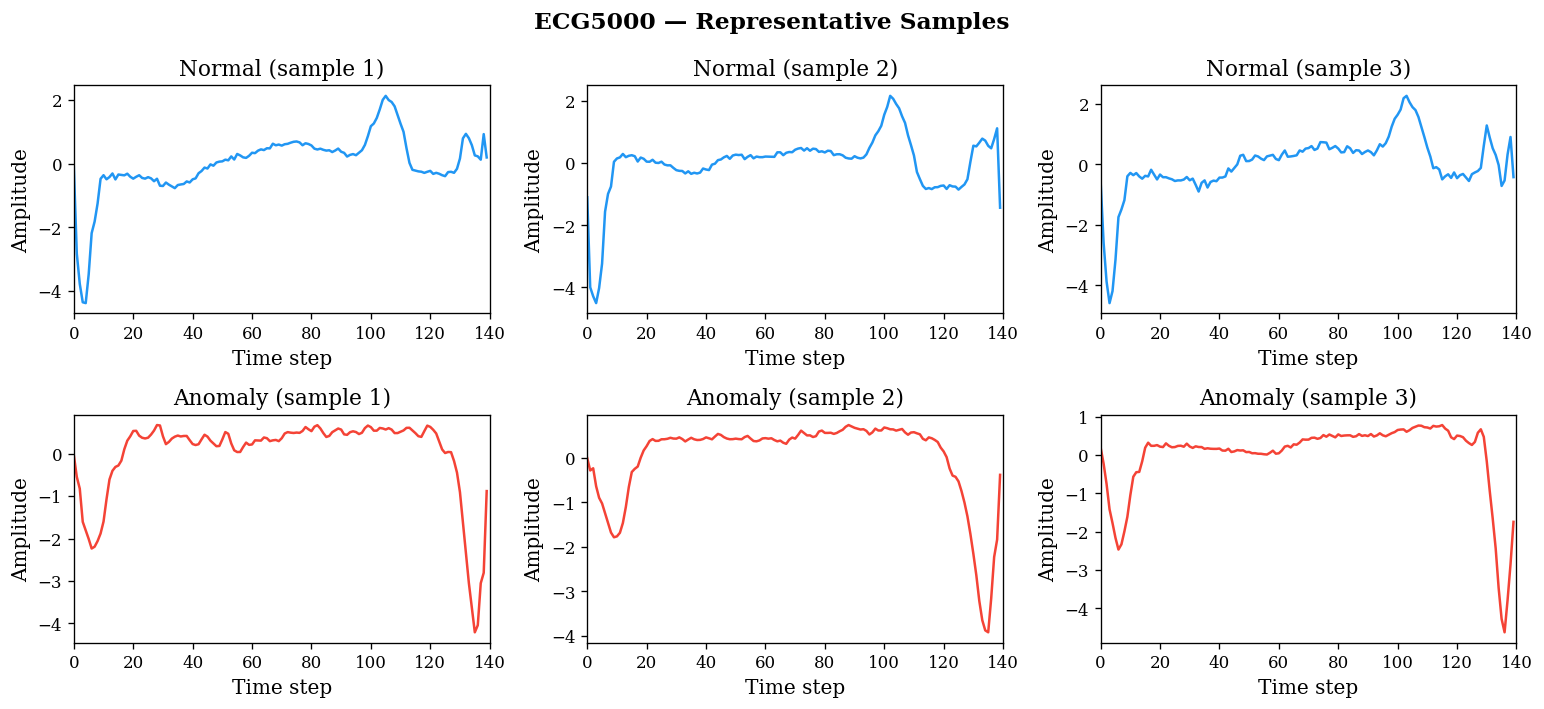

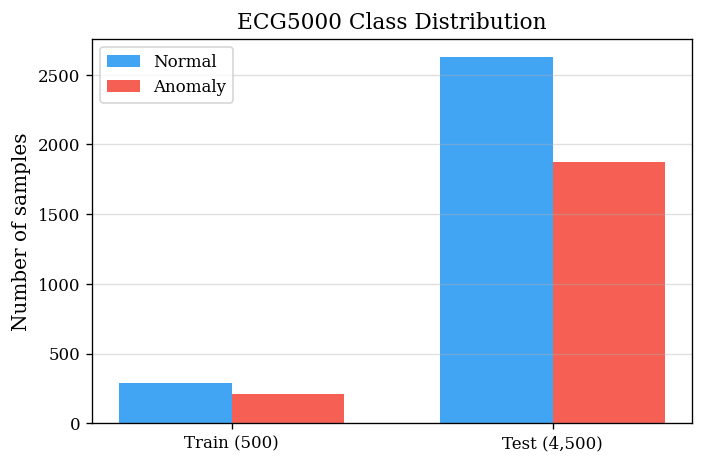

In [10]:
# Representative waveforms
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
fig.suptitle("ECG5000 — Representative Samples", fontsize=14, fontweight="bold")

normal_idx  = np.where(y_train == 0)[0]
anomaly_idx = np.where(y_train == 1)[0]

for col in range(3):
    axes[0, col].plot(X_train[normal_idx[col],  :, 0], color="#2196F3", lw=1.5)
    axes[0, col].set_title(f"Normal (sample {col + 1})")
    axes[0, col].set_ylabel("Amplitude")
    axes[0, col].set_xlabel("Time step")
    axes[0, col].set_xlim(0, N_TIMESTEPS)

    axes[1, col].plot(X_train[anomaly_idx[col], :, 0], color="#F44336", lw=1.5)
    axes[1, col].set_title(f"Anomaly (sample {col + 1})")
    axes[1, col].set_ylabel("Amplitude")
    axes[1, col].set_xlabel("Time step")
    axes[1, col].set_xlim(0, N_TIMESTEPS)

plt.tight_layout()
plt.savefig("fig_ecg_samples.png")
plt.show()

# Class distribution
fig, ax = plt.subplots(figsize=(6, 4))
splits    = ["Train (500)", "Test (4,500)"]
normals   = [int(np.sum(y_train == 0)), int(np.sum(y_test == 0))]
anomalies = [int(np.sum(y_train == 1)), int(np.sum(y_test == 1))]
x_pos = np.arange(len(splits))
w     = 0.35

ax.bar(x_pos - w / 2, normals,   w, label="Normal",  color="#2196F3", alpha=0.85)
ax.bar(x_pos + w / 2, anomalies, w, label="Anomaly", color="#F44336", alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(splits)
ax.set_ylabel("Number of samples")
ax.set_title("ECG5000 Class Distribution")
ax.legend()
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("fig_class_distribution.png")
plt.show()

## 5. Model Architecture

The SE-ECG model combines time-distributed dense layers, global average pooling,
and a Squeeze-and-Excitation (SE) channel-attention block.

**FPGA softmax design:** The output classifier uses two distinct Keras layers —
`Dense(2, name="output_logits")` followed by `Activation("softmax", name="output")`.
This enables extraction of a `logit_model` sub-model that terminates at the
raw Dense(2) output, which hls4ml converts reliably. A numerically stable
`numpy_softmax()` is applied in Python after reading FPGA logit predictions.

In [11]:
from tf_keras.layers import (
    Input, Dense, GlobalAveragePooling1D,
    Multiply, Add, BatchNormalization, Activation,
)
from tf_keras.models import Model


def build_se_ecg_model(seed: int = 42) -> Model:
    """
    Build the full SE-ECG model (logits + separate softmax) for training.

    Parameters
    ----------
    seed : int
        Random seed for weight initialisation.

    Returns
    -------
    Model
        Output shape (None, 2), softmax probabilities.
    """
    tf.random.set_seed(seed)
    np.random.seed(seed)

    inp = Input(shape=(N_TIMESTEPS, 1), name="ecg_input")

    # Stage 1 — Temporal embedding
    x = Dense(16, name="embedding")(inp)
    x = BatchNormalization(name="emb_bn")(x)
    x = Activation("relu", name="emb_relu")(x)

    # Stage 2 — Feed-forward network (time-distributed over 140 steps)
    ffn = Dense(32, name="ffn1")(x)
    ffn = BatchNormalization(name="ffn_bn")(ffn)
    ffn = Activation("relu", name="ffn_relu")(ffn)
    ffn = Dense(16, name="ffn2")(ffn)
    x   = Add(name="ffn_add")([x, ffn])          # residual connection

    # Stage 3 — Temporal aggregation
    x = BatchNormalization(name="final_bn")(x)
    x = GlobalAveragePooling1D(name="global_pool")(x)   # (batch, 16)

    # Stage 4 — SE channel-attention (all ops on 1-D vectors post-pooling)
    s     = Dense(8,  activation="relu",    name="se_dense1")(x)
    s     = Dense(16, activation="sigmoid", name="se_dense2")(s)
    x_att = Multiply(name="se_mult")([x, s])
    x     = Add(name="se_add")([x, x_att])

    # Stage 5 — Classifier (two separate layers — key for FPGA conversion)
    out_logits = Dense(2, name="output_logits")(x)
    out        = Activation("softmax", name="output")(out_logits)

    return Model(inp, out)


def build_logit_model(trained_model: Model) -> Model:
    """
    Extract a logit sub-model (Dense(2) output, no softmax) for FPGA conversion.

    Shares all weights with `trained_model`. Pass FPGA predictions through
    `numpy_softmax()` to obtain valid class probabilities.
    """
    return Model(
        inputs  = trained_model.input,
        outputs = trained_model.get_layer("output_logits").output,
        name    = "logit_model",
    )


def numpy_softmax(logits: np.ndarray) -> np.ndarray:
    """
    Numerically stable softmax over axis 1.

    Converts raw FPGA logit outputs to valid probability distributions.
    """
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_val = np.exp(shifted)
    return exp_val / exp_val.sum(axis=1, keepdims=True)


# Architecture verification
_demo       = build_se_ecg_model(seed=42)
_demo_logit = build_logit_model(_demo)

total_params     = _demo.count_params()
trainable_params = sum(tf.size(v).numpy() for v in _demo.trainable_variables)

_demo.summary()
print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Non-trainable (BN)   : {total_params - trainable_params:,}")

checks = {
    "output_logits layer present"  : any(l.name == "output_logits" for l in _demo.layers),
    "softmax activation separate"  : any(l.name == "output"         for l in _demo.layers),
    "no Reshape layers"            : not any("reshape" in l.name    for l in _demo.layers),
    "parameter count == 1,674"     : (total_params == 1674),
    "logit model ends at Dense(2)" : (_demo_logit.layers[-1].name == "output_logits"),
}
print("\nArchitecture checks:")
for description, passed in checks.items():
    print(f"  {'Passed' if passed else 'Failed'} {description}")

del _demo, _demo_logit

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 ecg_input (InputLayer)      [(None, 140, 1)]             0         []                            
                                                                                                  
 embedding (Dense)           (None, 140, 16)              32        ['ecg_input[0][0]']           
                                                                                                  
 emb_bn (BatchNormalization  (None, 140, 16)              64        ['embedding[0][0]']           
 )                                                                                                
                                                                                                  
 emb_relu (Activation)       (None, 140, 16)              0         ['emb_bn[0][0]']        

## 6. Multi-Seed Training

In [12]:
from tf_keras.optimizers import Adam
from tf_keras.callbacks  import EarlyStopping, ReduceLROnPlateau


def compute_all_metrics(y_true: np.ndarray, y_pred_proba: np.ndarray,
                        threshold: float = 0.5) -> dict:
    """
    Compute standard binary classification metrics from probability scores.

    Parameters
    ----------
    y_true       : ground-truth labels (0 = Normal, 1 = Anomaly).
    y_pred_proba : (N, 2) probability array; column 1 is P(Anomaly).
    threshold    : decision threshold applied to P(Anomaly).

    Returns
    -------
    dict with keys: accuracy, sensitivity, specificity, precision,
                    f1, auc, tn, fp, fn, tp.
    """
    y_pred = (y_pred_proba[:, 1] >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1          = (2 * precision * sensitivity / (precision + sensitivity)
                   if (precision + sensitivity) > 0 else 0.0)
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    auc         = roc_auc_score(y_true, y_pred_proba[:, 1])

    return {
        "accuracy":    accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision":   precision,
        "f1":          f1,
        "auc":         auc,
        "tn": int(tn), "fp": int(fp),
        "fn": int(fn), "tp": int(tp),
    }


# Class weights
# Balanced class weighting accounts for the 58 % / 42 % Normal/Anomaly split
# and prevents degenerate convergence to the majority class.
cw_values    = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
CLASS_WEIGHTS = dict(enumerate(cw_values.tolist()))
print(f"Class weights:  0 (Normal) = {CLASS_WEIGHTS[0]:.4f},  "
      f"1 (Anomaly) = {CLASS_WEIGHTS[1]:.4f}")


def train_single_run(seed: int, verbose: int = 0):
    """Train one model instance and return (model, history, metrics)."""
    model = build_se_ecg_model(seed=seed)
    model.compile(
        optimizer = Adam(learning_rate=LEARNING_RATE),
        loss      = "sparse_categorical_crossentropy",
        metrics   = ["accuracy"],
    )
    callbacks = [
        EarlyStopping(
            monitor="val_loss", patience=PATIENCE,
            restore_best_weights=True, verbose=0,
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=5, min_lr=1e-6, verbose=0,
        ),
    ]
    history = model.fit(
        X_train, y_train,
        validation_data = (X_test, y_test),
        epochs          = MAX_EPOCHS,
        batch_size      = BATCH_SIZE,
        callbacks       = callbacks,
        class_weight    = CLASS_WEIGHTS,
        verbose         = verbose,
    )
    y_proba           = model.predict(X_test, verbose=0)
    metrics           = compute_all_metrics(y_test, y_proba)
    metrics["epochs"] = len(history.history["loss"])
    return model, history, metrics


# Training loop
print(f"\nTraining {len(TRAINING_SEEDS)} seeds ...\n")
print(f"{'Seed':>6}  {'Acc':>7}  {'Sens':>7}  {'Spec':>7}  "
      f"{'F1':>7}  {'AUC':>7}  {'Ep':>4}  Status")
print("─" * 68)

all_results   = []
all_models    = []
all_histories = []

for seed in TRAINING_SEEDS:
    model, history, metrics = train_single_run(seed=seed)
    all_results.append(metrics)
    all_models.append(model)
    all_histories.append(history)

    is_ok  = metrics["sensitivity"] > 0.3 and metrics["specificity"] > 0.3
    status = "OK" if is_ok else "Degenerate"
    print(f"{seed:>6}  "
          f"{metrics['accuracy']:>7.4f}  {metrics['sensitivity']:>7.4f}  "
          f"{metrics['specificity']:>7.4f}  {metrics['f1']:>7.4f}  "
          f"{metrics['auc']:>7.4f}  {metrics['epochs']:>4}  {status}")

print("─" * 68)

# Summary statistics
print("\nMulti-seed summary (mean ± std):")
summary_stats = {}
for key in ["accuracy", "sensitivity", "specificity", "f1", "auc"]:
    vals = [r[key] for r in all_results]
    summary_stats[key] = {"mean": float(np.mean(vals)), "std": float(np.std(vals))}
    print(f"  {key:<14}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

Class weights:  0 (Normal) = 0.8562,  1 (Anomaly) = 1.2019

Training 5 seeds ...

  Seed      Acc     Sens     Spec       F1      AUC    Ep  Status
────────────────────────────────────────────────────────────────────
    42   0.9118   0.8420   0.9616   0.8882   0.9332    60  OK
   123   0.9104   0.8185   0.9760   0.8838   0.8857    34  OK
   456   0.6740   0.2477   0.9779   0.3875   0.8664    31  Degenerate
   789   0.8927   0.7512   0.9935   0.8535   0.8932    33  OK
  2024   0.8860   0.7314   0.9962   0.8423   0.9053    31  OK
────────────────────────────────────────────────────────────────────

Multi-seed summary (mean ± std):
  accuracy      : 0.8550 ± 0.0910
  sensitivity   : 0.6782 ± 0.2191
  specificity   : 0.9810 ± 0.0127
  f1            : 0.7711 ± 0.1926
  auc           : 0.8968 ± 0.0222


## 7. Best Model Selection

In [13]:
best_idx     = int(np.argmax([r["auc"] for r in all_results]))
best_seed    = TRAINING_SEEDS[best_idx]
best_model   = all_models[best_idx]
best_history = all_histories[best_idx]
best_metrics = all_results[best_idx]

print(f"Best seed   : {best_seed}")
print(f"AUC-ROC     : {best_metrics['auc']:.4f}")
print(f"Accuracy    : {best_metrics['accuracy']:.4f}")
print(f"Sensitivity : {best_metrics['sensitivity']:.4f}")
print(f"Specificity : {best_metrics['specificity']:.4f}")
print(f"F1-score    : {best_metrics['f1']:.4f}")
print(f"Epochs      : {best_metrics['epochs']}")

# Build logit model for FPGA conversion
logit_model = build_logit_model(best_model)
print(f"\nLogit model : {logit_model.name}")
print(f"  Input     : {logit_model.input_shape}")
print(f"  Output    : {logit_model.output_shape}  (raw Dense(2) logits)")

# Persist both model variants
best_model.save("best_ecg_model.h5")
logit_model.save("best_ecg_logit_model.h5", include_optimizer=False)
print("\nSaved: best_ecg_model.h5         (full model — softmax output)")
print("Saved: best_ecg_logit_model.h5   (logit model — FPGA conversion)")

Best seed   : 42
AUC-ROC     : 0.9332
Accuracy    : 0.9118
Sensitivity : 0.8420
Specificity : 0.9616
F1-score    : 0.8882
Epochs      : 60

Logit model : logit_model
  Input     : (None, 140, 1)
  Output    : (None, 2)  (raw Dense(2) logits)

Saved: best_ecg_model.h5         (full model — softmax output)
Saved: best_ecg_logit_model.h5   (logit model — FPGA conversion)


## 8. Training Dynamics

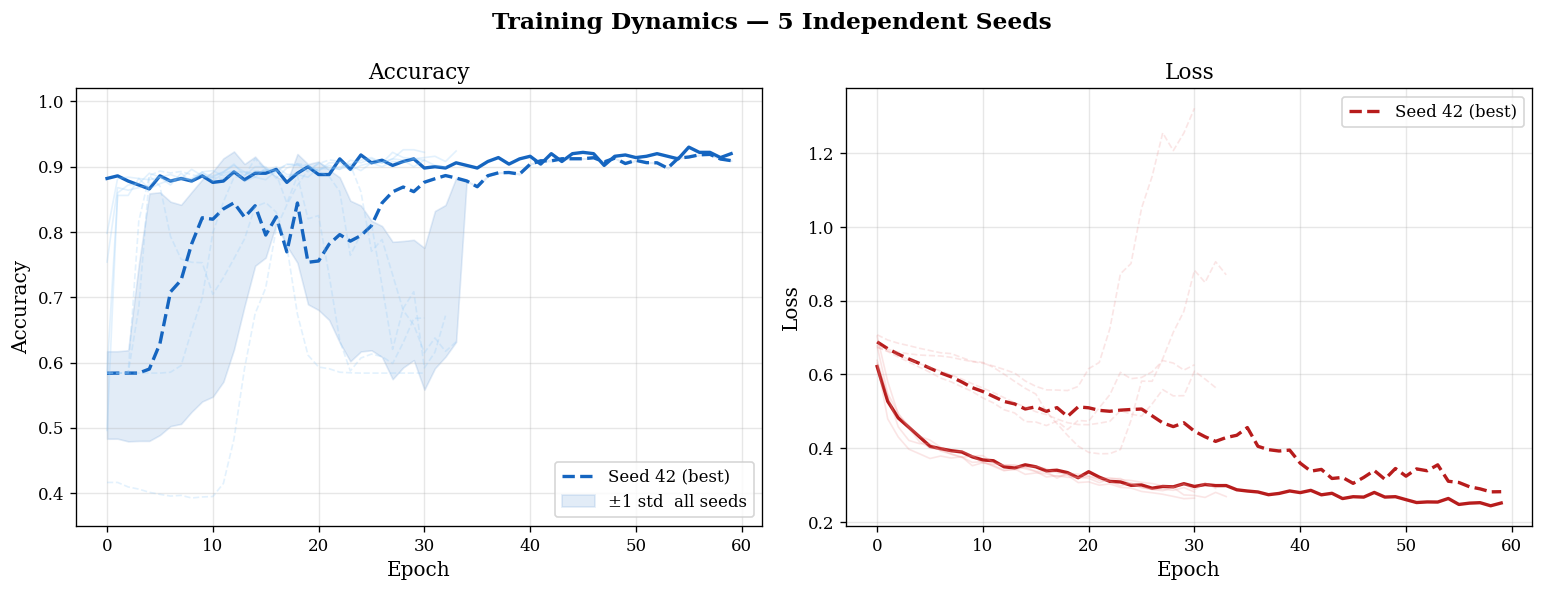

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Training Dynamics — 5 Independent Seeds",
             fontsize=14, fontweight="bold")

for idx, (history, seed) in enumerate(zip(all_histories, TRAINING_SEEDS)):
    is_best = (seed == best_seed)
    alpha   = 1.0 if is_best else 0.25
    lw      = 2.0 if is_best else 1.0
    label   = f"Seed {seed} (best)" if is_best else f"Seed {seed}"
    c_acc   = "#1565C0" if is_best else "#90CAF9"
    c_loss  = "#B71C1C" if is_best else "#EF9A9A"

    axes[0].plot(history.history["accuracy"],
                 color=c_acc, lw=lw, alpha=alpha)
    axes[0].plot(history.history["val_accuracy"],
                 color=c_acc, lw=lw, alpha=alpha, linestyle="--",
                 label=label if is_best else None)

    axes[1].plot(history.history["loss"],
                 color=c_loss, lw=lw, alpha=alpha)
    axes[1].plot(history.history["val_loss"],
                 color=c_loss, lw=lw, alpha=alpha, linestyle="--",
                 label=label if is_best else None)

# ±1 std band across all seeds on validation accuracy
max_len = max(len(h.history["val_accuracy"]) for h in all_histories)
padded  = np.array([
    np.pad(h.history["val_accuracy"],
           (0, max_len - len(h.history["val_accuracy"])),
           constant_values=np.nan)
    for h in all_histories
])
xs       = np.arange(max_len)
mean_val = np.nanmean(padded, axis=0)
std_val  = np.nanstd(padded,  axis=0)
axes[0].fill_between(xs, mean_val - std_val, mean_val + std_val,
                     alpha=0.12, color="#1565C0", label="±1 std  all seeds")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy")
axes[0].legend(loc="lower right")
axes[0].set_ylim(0.35, 1.02)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_training_curves.png")
plt.show()

## 9. Software Model Evaluation

Full evaluation on the 4,500-sample test set using the best-seed softmax model.

Software Model — Full Test Set (N = 4,500)
              precision    recall  f1-score   support

      Normal     0.8951    0.9616    0.9271      2627
     Anomaly     0.9398    0.8420    0.8882      1873

    accuracy                         0.9118      4500
   macro avg     0.9175    0.9018    0.9077      4500
weighted avg     0.9137    0.9118    0.9109      4500

AUC-ROC : 0.9332


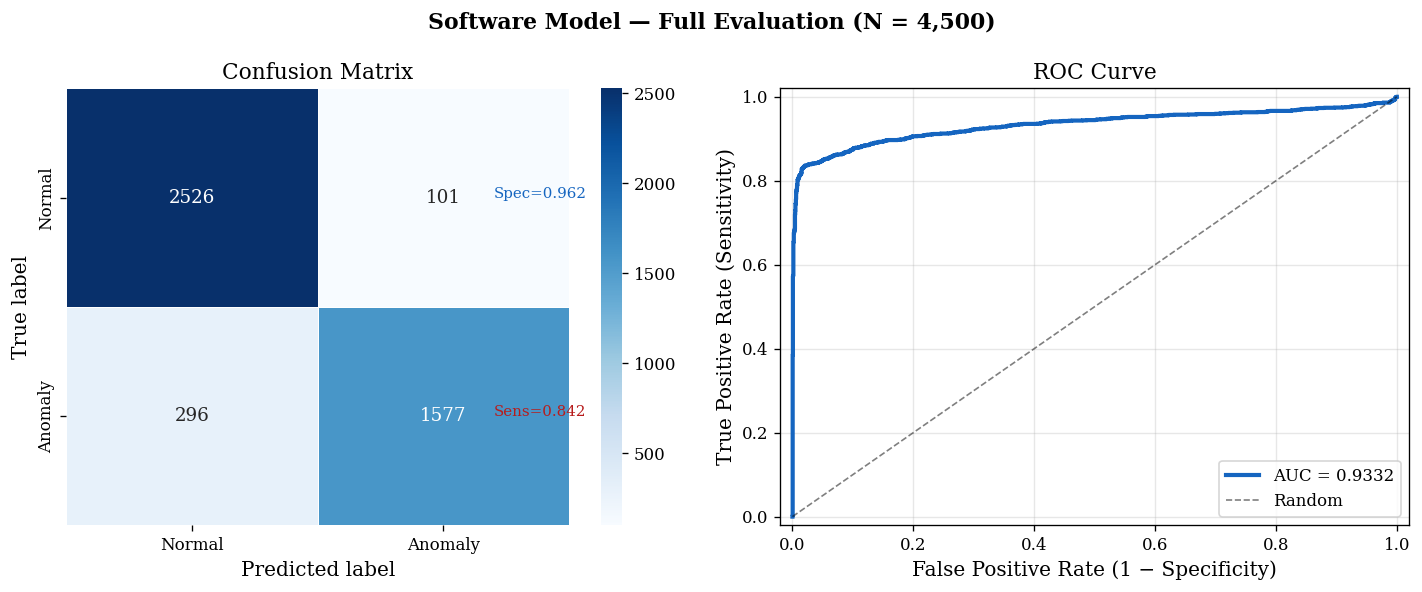

In [16]:
y_proba_sw_full = best_model.predict(X_test, verbose=0)
y_pred_sw_full  = np.argmax(y_proba_sw_full, axis=1)
cm_sw_full      = confusion_matrix(y_test, y_pred_sw_full)
auc_sw_full     = roc_auc_score(y_test, y_proba_sw_full[:, 1])

print("=" * 55)
print("Software Model — Full Test Set (N = 4,500)")
print("=" * 55)
print(classification_report(
    y_test, y_pred_sw_full,
    target_names=["Normal", "Anomaly"],
    digits=4,
))
print(f"AUC-ROC : {auc_sw_full:.4f}")

# Confusion matrix + ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba_sw_full[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Software Model — Full Evaluation (N = 4,500)", fontweight="bold")

sns.heatmap(
    cm_sw_full, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal", "Anomaly"],
    yticklabels=["Normal", "Anomaly"],
    ax=axes[0], linewidths=0.5,
)
tn_s, fp_s, fn_s, tp_s = cm_sw_full.ravel()
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_title("Confusion Matrix")
axes[0].text(1.7, 0.5, f"Spec={tn_s/(tn_s+fp_s):.3f}", fontsize=9, color="#1565C0")
axes[0].text(1.7, 1.5, f"Sens={tp_s/(tp_s+fn_s):.3f}", fontsize=9, color="#B71C1C")

axes[1].plot(fpr, tpr, color="#1565C0", lw=2.5, label=f"AUC = {auc_sw_full:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")
axes[1].set_xlabel("False Positive Rate (1 − Specificity)")
axes[1].set_ylabel("True Positive Rate (Sensitivity)")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)
axes[1].set_xlim([-0.02, 1.02])
axes[1].set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig("fig_sw_evaluation.png")
plt.show()

## 10. FPGA Conversion & Precision Sweep

The logit model (no softmax) is converted to HLS using hls4ml.
A quick sweep over candidate fixed-point precisions on 200 samples identifies
the best setting before compiling the final models at full evaluation scale.

**Precision rationale:** After `GlobalAveragePooling1D` (averaging over 140
time steps), intermediate values enter a small range that benefits from
additional fractional bits. `ap_fixed<16,8>` leaves only ~10–25 quantisation
levels for these values; `ap_fixed<24,12>` provides 16× finer resolution
and is selected as the main precision.

In [17]:
# Stratified validation subset
# Created once here; reused in Sections 12–15.
sss = StratifiedShuffleSplit(n_splits=1, test_size=N_VERIFY, random_state=VERIFY_SEED)
for _, verify_idx in sss.split(X_test, y_test):
    X_verify = np.ascontiguousarray(X_test[verify_idx])
    y_verify = y_test[verify_idx]

n_normal_verify  = int(np.sum(y_verify == 0))
n_anomaly_verify = int(np.sum(y_verify == 1))
print(f"Validation subset : {n_normal_verify} Normal / "
      f"{n_anomaly_verify} Anomaly  (N = {N_VERIFY})\n")

# Precision candidates
PRECISION_CANDIDATES = [
    ("16-bit", "ap_fixed<16,8>",  True),
    ("20-bit", "ap_fixed<20,10>", True),
    ("24-bit", "ap_fixed<24,12>", True),
    ("12-bit", "ap_fixed<12,6>",  True),
    ("8-bit",  "ap_fixed<8,4>",   False),  # included for reference; expected to degrade
]

N_SWEEP_SAMPLES = 200
sweep_probe_x   = np.ascontiguousarray(X_verify[:N_SWEEP_SAMPLES])
sweep_probe_y   = y_verify[:N_SWEEP_SAMPLES]

sw_logits_sweep = logit_model.predict(sweep_probe_x, verbose=0)
sw_proba_sweep  = numpy_softmax(sw_logits_sweep)
sw_pred_sweep   = np.argmax(sw_logits_sweep, axis=1)
sw_auc_sweep    = roc_auc_score(sweep_probe_y, sw_proba_sweep[:, 1])
print(f"SW reference (N = {N_SWEEP_SAMPLES}) : AUC = {sw_auc_sweep:.4f}")
print("Running precision sweep ...\n")

# First pass: compile and evaluate all precisions
sweep_results = {}

for label, prec_str, _ in PRECISION_CANDIDATES:
    out_dir = f"hls_sweep_{prec_str.replace('<','').replace('>','').replace(',','_')}"
    cfg = hls4ml.utils.config_from_keras_model(
        logit_model, granularity="name", default_precision=prec_str
    )
    for lname in cfg["LayerName"]:
        cfg["LayerName"][lname]["Strategy"]    = "Latency"
        cfg["LayerName"][lname]["ReuseFactor"] = REUSE_FACTOR

    try:
        hls_m = hls4ml.converters.convert_from_keras_model(
            logit_model, hls_config=cfg, output_dir=out_dir, part=FPGA_PART
        )
        hls_m.compile()

        hw_logits = hls_m.predict(sweep_probe_x)
        hw_proba  = numpy_softmax(hw_logits)
        hw_pred   = np.argmax(hw_logits, axis=1)

        hw_auc  = roc_auc_score(sweep_probe_y, hw_proba[:, 1])
        hw_sens = recall_score(sweep_probe_y, hw_pred, pos_label=1, zero_division=0)
        hw_spec = recall_score(sweep_probe_y, hw_pred, pos_label=0, zero_division=0)
        fid     = accuracy_score(sw_pred_sweep, hw_pred)

        sweep_results[prec_str] = {
            "label": label, "auc": hw_auc, "sens": hw_sens,
            "spec": hw_spec, "fidelity": fid,
            "degenerate": (hw_sens < 0.05 or hw_spec < 0.05),
        }

    except Exception as exc:
        print(f"  {label}: compilation failed — {exc}")
        sweep_results[prec_str] = {
            "label": label, "auc": 0.0, "degenerate": True, "failed": True,
        }

# Second pass: select best precision, then print results table
valid     = {k: v for k, v in sweep_results.items()
             if not v.get("degenerate", True) and not v.get("failed", False)}
best_prec = max(valid, key=lambda k: valid[k]["auc"]) if valid else "ap_fixed<16,8>"

print(f"{'Precision':<22} {'HW AUC':>8} {'Sens':>7} {'Spec':>7} "
      f"{'Fidelity':>9}  Status")
print("─" * 68)
for label, prec_str, _ in PRECISION_CANDIDATES:
    res = sweep_results.get(prec_str, {})
    if res.get("failed"):
        print(f"  {label:<20} {'FAILED':>48}")
        continue
    if res.get("degenerate"):
        status = "Degenerate"
    elif prec_str == best_prec:
        status = "Best"
    else:
        status = "OK"
    print(f"  {label:<20} {res['auc']:>8.4f} {res['sens']:>7.4f} "
          f"{res['spec']:>7.4f} {res['fidelity']:>9.4f}  {status}")
print("─" * 68)
print(f"  {'SW reference':<20} {sw_auc_sweep:>8.4f}  (target)\n")
print(f"Selected precision: {best_prec}")

# Compile final models
FIXED_POINT_MAIN = best_prec

cfg_main = hls4ml.utils.config_from_keras_model(
    logit_model, granularity="name", default_precision=FIXED_POINT_MAIN
)
for lname in cfg_main["LayerName"]:
    cfg_main["LayerName"][lname]["Strategy"]    = "Latency"
    cfg_main["LayerName"][lname]["ReuseFactor"] = REUSE_FACTOR

hls_model = hls4ml.converters.convert_from_keras_model(
    logit_model, hls_config=cfg_main,
    output_dir=HLS_OUTPUT_DIR, part=FPGA_PART,
)
hls_model.compile()
print(f"Main  model compiled : {FIXED_POINT_MAIN}")

cfg_light = hls4ml.utils.config_from_keras_model(
    logit_model, granularity="name", default_precision=FIXED_POINT_LIGHT
)
for lname in cfg_light["LayerName"]:
    cfg_light["LayerName"][lname]["Strategy"]    = "Latency"
    cfg_light["LayerName"][lname]["ReuseFactor"] = REUSE_FACTOR

hls_model_light = hls4ml.converters.convert_from_keras_model(
    logit_model, hls_config=cfg_light,
    output_dir=HLS_OUTPUT_LIGHT, part=FPGA_PART,
)
hls_model_light.compile()
print(f"Light model compiled : {FIXED_POINT_LIGHT}")

Validation subset : 584 Normal / 416 Anomaly  (N = 1000)

SW reference (N = 200) : AUC = 0.9245
Running precision sweep ...

Precision                HW AUC    Sens    Spec  Fidelity  Status
────────────────────────────────────────────────────────────────────
  16-bit                 0.7180  0.6588  0.8000    0.8250  OK
  20-bit                 0.9223  0.8000  0.9652    1.0000  OK
  24-bit                 0.9240  0.8000  0.9652    1.0000  Best
  12-bit                 0.2626  0.2471  0.4522    0.3900  OK
  8-bit                  0.5000  0.0000  1.0000    0.6400  Degenerate
────────────────────────────────────────────────────────────────────
  SW reference           0.9245  (target)

Selected precision: ap_fixed<24,12>
Main  model compiled : ap_fixed<24,12>
Light model compiled : ap_fixed<12,6>


## 11. Hardware Evaluation

Full evaluation on the 1,000-sample stratified subset.
Software predictions use `logit_model` + `numpy_softmax` to ensure a fair
comparison on identical probability outputs.

In [19]:
print("Running predictions ...\n")

# Software (float32)
y_sw_logits = logit_model.predict(X_verify, verbose=0)
y_sw_proba  = numpy_softmax(y_sw_logits)
y_pred_sw   = np.argmax(y_sw_logits, axis=1)

# Main hardware model
y_hw_main_logits = hls_model.predict(X_verify)
y_hw_main_proba  = numpy_softmax(y_hw_main_logits)
y_pred_hw_main   = np.argmax(y_hw_main_logits, axis=1)

# Light hardware model
y_hw_light_logits = hls_model_light.predict(X_verify)
y_hw_light_proba  = numpy_softmax(y_hw_light_logits)
y_pred_hw_light   = np.argmax(y_hw_light_logits, axis=1)

# Metrics
sw_metrics       = compute_all_metrics(y_verify, y_sw_proba)
hw_main_metrics  = compute_all_metrics(y_verify, y_hw_main_proba)
hw_light_metrics = compute_all_metrics(y_verify, y_hw_light_proba)
fidelity_main    = accuracy_score(y_pred_sw, y_pred_hw_main)
fidelity_light   = accuracy_score(y_pred_sw, y_pred_hw_light)

# Confirm normalisation
for name, proba in [("main", y_hw_main_proba), ("light", y_hw_light_proba)]:
    err = np.abs(proba.sum(axis=1) - 1.0).max()
    print(f"  {name} normalisation check : max|sum−1| = {err:.2e} ")

# Results table
col_w = 14
print(f"\n{'Metric':<20} {'SW float32':>{col_w}} "
      f"{FIXED_POINT_MAIN:>{col_w}} {FIXED_POINT_LIGHT:>{col_w}}")
print("=" * (20 + col_w * 3 + 3))
for label, key in [
    ("Accuracy",    "accuracy"),
    ("Sensitivity", "sensitivity"),
    ("Specificity", "specificity"),
    ("F1-score",    "f1"),
    ("AUC-ROC",     "auc"),
]:
    print(f"  {label:<18} {sw_metrics[key]:>{col_w}.4f} "
          f"{hw_main_metrics[key]:>{col_w}.4f} {hw_light_metrics[key]:>{col_w}.4f}")
print("─" * (20 + col_w * 3 + 3))
print(f"  {'Logic Fidelity':<18} {'—':>{col_w}} "
      f"{fidelity_main:>{col_w}.4f} {fidelity_light:>{col_w}.4f}")
print(f"  {'Disagreements':<18} {'—':>{col_w}} "
      f"{N_VERIFY - int(fidelity_main  * N_VERIFY):>{col_w}d} "
      f"{N_VERIFY - int(fidelity_light * N_VERIFY):>{col_w}d}")
print("=" * (20 + col_w * 3 + 3))

# Diagnosis
print("\nDiagnosis:")
for name, met, fid in [("Main  HW", hw_main_metrics, fidelity_main),
                        ("Light HW", hw_light_metrics, fidelity_light)]:
    s, sp, a = met["sensitivity"], met["specificity"], met["auc"]
    if s < 0.05 or sp < 0.05:
        verdict = "Degenerate — single class predicted"
    elif a > 0.85 and fid > 0.85:
        verdict = "Good — close to software baseline"
    elif a > 0.70:
        verdict = f"Functional — AUC = {a:.3f}, fidelity = {fid:.3f}"
    else:
        verdict = f"Poor — AUC = {a:.3f}"
    print(f"  {name} : {verdict}")

Running predictions ...

  main normalisation check : max|sum−1| = 1.19e-07 
  light normalisation check : max|sum−1| = 5.96e-08 

Metric                   SW float32 ap_fixed<24,12> ap_fixed<12,6>
  Accuracy                   0.9130         0.9140         0.3600
  Sensitivity                0.8438         0.8438         0.3221
  Specificity                0.9623         0.9640         0.3870
  F1-score                   0.8897         0.8909         0.2952
  AUC-ROC                    0.9287         0.9284         0.2881
─────────────────────────────────────────────────────────────────
  Logic Fidelity                  —         0.9990         0.3820
  Disagreements                   —              1            618

Diagnosis:
  Main  HW : Good — close to software baseline
  Light HW : Poor — AUC = 0.288


## 12. Confusion Matrices

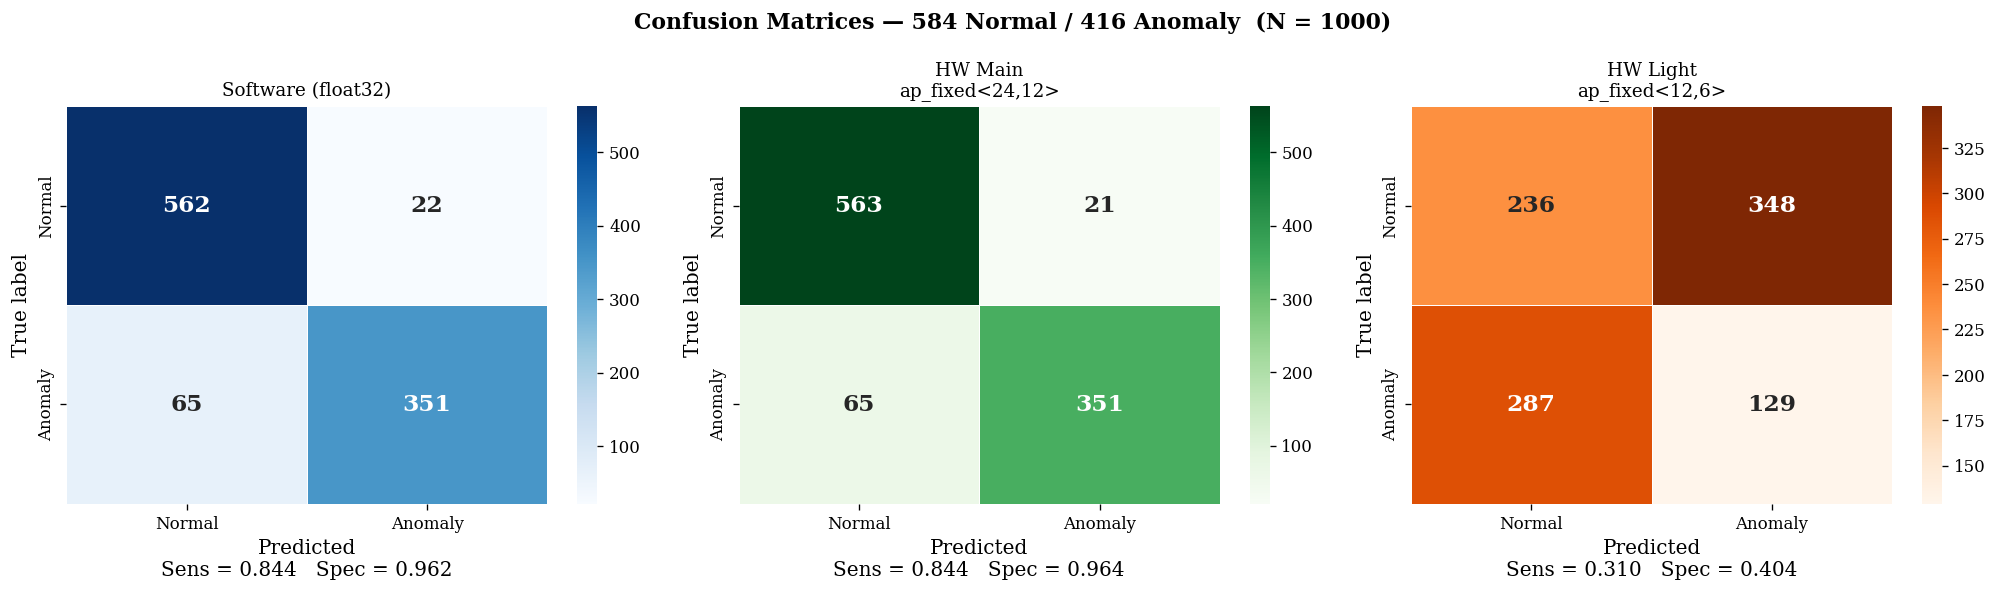

In [20]:
cm_sw    = confusion_matrix(y_verify, y_pred_sw)
cm_main  = confusion_matrix(y_verify, y_pred_hw_main)
cm_light = confusion_matrix(y_verify, y_pred_hw_light)


def _plot_cm(ax, cm, title, cmap="Blues"):
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap,
        xticklabels=["Normal", "Anomaly"],
        yticklabels=["Normal", "Anomaly"],
        ax=ax, linewidths=0.5,
        annot_kws={"size": 14, "weight": "bold"},
    )
    tn_c, fp_c, fn_c, tp_c = cm.ravel()
    spec = tn_c / (tn_c + fp_c) if (tn_c + fp_c) > 0 else 0.0
    sens = tp_c / (tp_c + fn_c) if (tp_c + fn_c) > 0 else 0.0
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(f"Predicted\nSens = {sens:.3f}   Spec = {spec:.3f}")
    ax.set_ylabel("True label")


fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f"Confusion Matrices — "
    f"{n_normal_verify} Normal / {n_anomaly_verify} Anomaly  (N = {N_VERIFY})",
    fontweight="bold",
)

_plot_cm(axes[0], cm_sw,    "Software (float32)",          cmap="Blues")
_plot_cm(axes[1], cm_main,  f"HW Main\n{FIXED_POINT_MAIN}",   cmap="Greens")
_plot_cm(axes[2], cm_light, f"HW Light\n{FIXED_POINT_LIGHT}",  cmap="Oranges")

plt.tight_layout()
plt.savefig("fig_confusion_matrices.png")
plt.show()

## 13. Software–Hardware Agreement

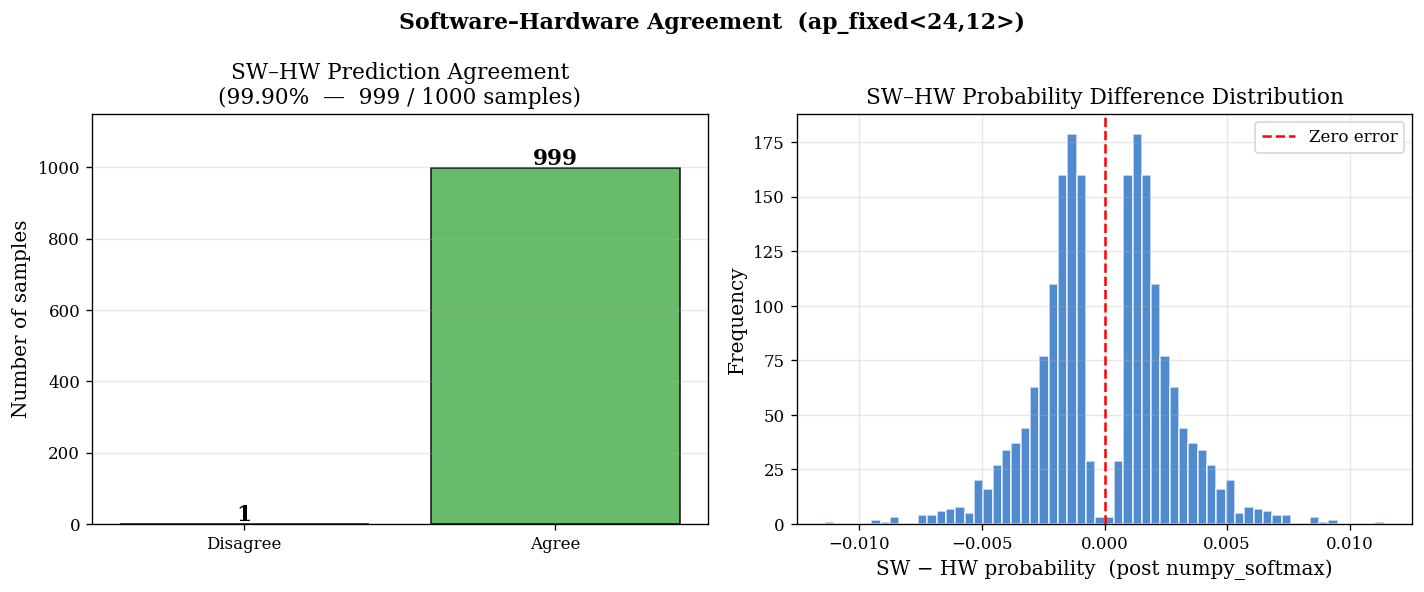

Disagreement analysis (1 samples):
  True label Normal  : 1
  True label Anomaly : 0
  Max  |SW−HW| diff  : 0.011415
  Mean |SW−HW| diff  : 0.002274


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    f"Software–Hardware Agreement  ({FIXED_POINT_MAIN})",
    fontweight="bold",
)

# Prediction agreement bar chart
agree  = (y_pred_sw == y_pred_hw_main).astype(int)
counts = np.bincount(agree, minlength=2)
axes[0].bar(["Disagree", "Agree"], counts,
            color=["#F44336", "#4CAF50"], alpha=0.85, edgecolor="black")
for i, c in enumerate(counts):
    axes[0].text(i, c + 8, str(c), ha="center", fontweight="bold", fontsize=13)
axes[0].set_ylabel("Number of samples")
axes[0].set_title(
    f"SW–HW Prediction Agreement\n"
    f"({100 * fidelity_main:.2f}%  —  "
    f"{int(fidelity_main * N_VERIFY)} / {N_VERIFY} samples)"
)
axes[0].set_ylim(0, N_VERIFY * 1.15)
axes[0].grid(axis="y", alpha=0.3)

# Probability error distribution
error_main = y_sw_proba - y_hw_main_proba
axes[1].hist(error_main.flatten(), bins=60,
             color="#1565C0", alpha=0.75, edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", lw=1.5, label="Zero error")
axes[1].set_xlabel("SW − HW probability  (post numpy_softmax)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("SW–HW Probability Difference Distribution")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_sw_hw_agreement.png")
plt.show()

# Disagreement breakdown
disagree_idx = np.where(y_pred_sw != y_pred_hw_main)[0]
print(f"Disagreement analysis ({len(disagree_idx)} samples):")
print(f"  True label Normal  : {np.sum(y_verify[disagree_idx] == 0)}")
print(f"  True label Anomaly : {np.sum(y_verify[disagree_idx] == 1)}")
print(f"  Max  |SW−HW| diff  : {np.abs(error_main).max():.6f}")
print(f"  Mean |SW−HW| diff  : {np.abs(error_main).mean():.6f}")

## 14. Results Export

All quantitative results are serialised to `paper_numbers.json` for use in
manuscript tables and reproducibility verification.

In [22]:
paper_numbers = {
    "dataset": {
        "train_total"  : int(len(X_train)),
        "train_normal" : int(np.sum(y_train == 0)),
        "train_anomaly": int(np.sum(y_train == 1)),
        "test_total"   : int(len(X_test)),
        "test_normal"  : int(np.sum(y_test == 0)),
        "test_anomaly" : int(np.sum(y_test == 1)),
    },
    "model": {
        "total_params"    : int(total_params),
        "trainable_params": int(trainable_params),
        "architecture"    : (
            "SE channel-attention after GlobalAveragePooling1D. "
            "No broadcasting — all Multiply ops use same-shape (16,) tensors. "
            "Logit model (Dense(2), no softmax) converted to FPGA."
        ),
    },
    "training_seeds": TRAINING_SEEDS,
    "class_weights" : CLASS_WEIGHTS,
    "multi_seed_summary": {
        k: {"mean": summary_stats[k]["mean"], "std": summary_stats[k]["std"]}
        for k in ["accuracy", "sensitivity", "specificity", "f1", "auc"]
    },
    "best_seed": int(best_seed),
    # Metrics on the full 4,500-sample test set (float32 model)
    "best_model_full_test": {
        **{k: float(v) for k, v in best_metrics.items() if isinstance(v, float)},
        "epochs_trained": int(best_metrics["epochs"]),
    },
    # Metrics on the 1,000-sample stratified verification subset
    "hardware_eval_main": {
        "fixed_point"   : FIXED_POINT_MAIN,
        "softmax_method": "numpy (hls4ml C-sim softmax bypassed)",
        "n_verify"      : int(N_VERIFY),
        "n_normal"      : int(n_normal_verify),
        "n_anomaly"     : int(n_anomaly_verify),
        "sw_accuracy"   : float(sw_metrics["accuracy"]),
        "sw_sensitivity": float(sw_metrics["sensitivity"]),
        "sw_specificity": float(sw_metrics["specificity"]),
        "sw_f1"         : float(sw_metrics["f1"]),
        "sw_auc"        : float(sw_metrics["auc"]),
        "hw_accuracy"   : float(hw_main_metrics["accuracy"]),
        "hw_sensitivity": float(hw_main_metrics["sensitivity"]),
        "hw_specificity": float(hw_main_metrics["specificity"]),
        "hw_f1"         : float(hw_main_metrics["f1"]),
        "hw_auc"        : float(hw_main_metrics["auc"]),
        "logic_fidelity": float(fidelity_main),
        "disagreements" : int(N_VERIFY - int(fidelity_main * N_VERIFY)),
    },
    "hardware_eval_light": {
        "fixed_point"   : FIXED_POINT_LIGHT,
        "hw_accuracy"   : float(hw_light_metrics["accuracy"]),
        "hw_sensitivity": float(hw_light_metrics["sensitivity"]),
        "hw_specificity": float(hw_light_metrics["specificity"]),
        "hw_f1"         : float(hw_light_metrics["f1"]),
        "hw_auc"        : float(hw_light_metrics["auc"]),
        "logic_fidelity": float(fidelity_light),
        "disagreements" : int(N_VERIFY - int(fidelity_light * N_VERIFY)),
    },
    "precision_sweep": {
        prec: {
            "auc"       : float(res["auc"]),
            "sens"      : float(res.get("sens", 0.0)),
            "spec"      : float(res.get("spec", 0.0)),
            "degenerate": bool(res.get("degenerate", True)),
        }
        for prec, res in sweep_results.items()
    },
    "fpga_config": {
        "precision_main"   : FIXED_POINT_MAIN,
        "precision_light"  : FIXED_POINT_LIGHT,
        "reuse_factor"     : REUSE_FACTOR,
        "target_device"    : FPGA_PART,
        "hls4ml_version"   : hls4ml.__version__,
        "model_converted"  : "logit_model (Dense(2) only, no softmax)",
        "softmax_note"     : (
            "hls4ml 1.3.0 C-simulation softmax bypassed. "
            "Raw logits output by FPGA; numpy_softmax applied in Python."
        ),
    },
}

with open("paper_numbers.json", "w") as fh:
    json.dump(paper_numbers, fh, indent=2)

print("Saved: paper_numbers.json\n")

# Final summary
W = 52
print("═" * W)
print("  Results Summary")
print("═" * W)
print(f"\n  Software model  (N = 4,500, float32)")
print(f"    AUC-ROC      : {best_metrics['auc']:.4f}")
print(f"    Accuracy     : {best_metrics['accuracy']:.4f}")
print(f"    Sensitivity  : {best_metrics['sensitivity']:.4f}")
print(f"    Specificity  : {best_metrics['specificity']:.4f}")
print(f"    F1-score     : {best_metrics['f1']:.4f}")
print(f"    Epochs       : {best_metrics['epochs']}")

print(f"\n  Hardware main   (N = {N_VERIFY}, {FIXED_POINT_MAIN})")
print(f"    AUC-ROC      : {hw_main_metrics['auc']:.4f}")
print(f"    Accuracy     : {hw_main_metrics['accuracy']:.4f}")
print(f"    Sensitivity  : {hw_main_metrics['sensitivity']:.4f}")
print(f"    Specificity  : {hw_main_metrics['specificity']:.4f}")
print(f"    F1-score     : {hw_main_metrics['f1']:.4f}")
print(f"    Fidelity     : {fidelity_main:.4f}  "
      f"({int(fidelity_main * N_VERIFY)}/{N_VERIFY} agree)")

print(f"\n  Hardware light  (N = {N_VERIFY}, {FIXED_POINT_LIGHT})")
print(f"    AUC-ROC      : {hw_light_metrics['auc']:.4f}")
print(f"    Fidelity     : {fidelity_light:.4f}  "
      f"({int(fidelity_light * N_VERIFY)}/{N_VERIFY} agree)")

print(f"\n  Multi-seed (5 runs, full test set)")
print(f"    AUC  mean±std : "
      f"{summary_stats['auc']['mean']:.4f} ± {summary_stats['auc']['std']:.4f}")
print(f"    Sens mean±std : "
      f"{summary_stats['sensitivity']['mean']:.4f} ± "
      f"{summary_stats['sensitivity']['std']:.4f}")

print(f"\n  Model parameters : {total_params:,} total  "
      f"({trainable_params:,} trainable)")
print(f"  Target device    : {FPGA_PART}")
print(f"  Best seed        : {best_seed}")
print("═" * W)

Saved: paper_numbers.json

════════════════════════════════════════════════════
  Results Summary
════════════════════════════════════════════════════

  Software model  (N = 4,500, float32)
    AUC-ROC      : 0.9332
    Accuracy     : 0.9118
    Sensitivity  : 0.8420
    Specificity  : 0.9616
    F1-score     : 0.8882
    Epochs       : 60

  Hardware main   (N = 1000, ap_fixed<24,12>)
    AUC-ROC      : 0.9284
    Accuracy     : 0.9140
    Sensitivity  : 0.8438
    Specificity  : 0.9640
    F1-score     : 0.8909
    Fidelity     : 0.9990  (999/1000 agree)

  Hardware light  (N = 1000, ap_fixed<12,6>)
    AUC-ROC      : 0.2881
    Fidelity     : 0.3820  (382/1000 agree)

  Multi-seed (5 runs, full test set)
    AUC  mean±std : 0.8968 ± 0.0222
    Sens mean±std : 0.6782 ± 0.2191

  Model parameters : 1,674 total  (1,546 trainable)
  Target device    : xc7z020clg400-1
  Best seed        : 42
════════════════════════════════════════════════════
